In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **LOAD DATASET**

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data.csv')

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 871 entries, 0 to 870
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   AnimalName  871 non-null    object
 1   symptoms1   871 non-null    object
 2   symptoms2   871 non-null    object
 3   symptoms3   871 non-null    object
 4   symptoms4   871 non-null    object
 5   symptoms5   871 non-null    object
 6   Dangerous   869 non-null    object
dtypes: object(7)
memory usage: 47.8+ KB
None


In [ ]:
print(df.head())

  AnimalName symptoms1             symptoms2 symptoms3    symptoms4  \
0        Dog     Fever              Diarrhea  Vomiting  Weight loss   
1        Dog     Fever              Diarrhea  Coughing    Tiredness   
2        Dog     Fever              Diarrhea  Coughing     Vomiting   
3        Dog     Fever  Difficulty breathing  Coughing     Lethargy   
4        Dog     Fever              Diarrhea  Coughing     Lethargy   

     symptoms5 Dangerous  
0  Dehydration       Yes  
1        Pains       Yes  
2     Anorexia       Yes  
3     Sneezing       Yes  
4     Blue Eye       Yes  


In [ ]:
# Menampilkan nama kolom dalam dataset
print(df.columns)

Index(['AnimalName', 'symptoms1', 'symptoms2', 'symptoms3', 'symptoms4',
       'symptoms5', 'Dangerous'],
      dtype='object')


In [ ]:
# ... (Your existing code) ...
# %%
# Menampilkan nama kolom dalam dataset
print(df.columns)
# %%
df['description'] = df[['symptoms1', 'symptoms2', 'symptoms3', 'symptoms4', 'symptoms5']].astype(str).agg(' '.join, axis=1)

# Menentukan kolom teks dan label
text_column = 'description'
label_column = 'Dangerous'

# Pastikan label dalam bentuk numerik
df[label_column] = df[label_column].astype('category').cat.codes
# Ensure label values are within the expected range
df[label_column] = df[label_column].clip(lower=0)

# Verify if labels contain -1:
if -1 in df[label_column].unique():
  print("Warning: Label column contains -1. This might cause issues during training.")

# Check for missing labels or NaN values:
print(df[label_column].isnull().sum())  # Check for NaN values
print(df[label_column].eq('').sum())   # Check for empty strings

# ... (Rest of your code) ...

Index(['AnimalName', 'symptoms1', 'symptoms2', 'symptoms3', 'symptoms4',
       'symptoms5', 'Dangerous'],
      dtype='object')
0
0


# **Menghapus data yang kosong**

In [ ]:
df = df.dropna(subset=[text_column, label_column])

# **Load tokenizer BERT**

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(texts):
    return tokenizer(texts, padding='max_length', truncation=True, max_length=512, return_tensors="pt")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


# **Membagi dataset menjadi train (80%), validation (10%), dan test (10%)**

In [ ]:
texts = df[text_column].tolist()
labels = df[label_column].tolist()
train_texts, temp_texts, train_labels, temp_labels = train_test_split(texts, labels, test_size=0.2, random_state=42)
val_texts, test_texts, val_labels, test_labels = train_test_split(temp_texts, temp_labels, test_size=0.5, random_state=42)

# **Tokenisasi semua teks**

In [ ]:
train_encodings = tokenize_function(train_texts)
val_encodings = tokenize_function(val_texts)
test_encodings = tokenize_function(test_texts)

# **Konversi ke format Dataset PyTorch**

In [ ]:
class AnimalConditionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_dataset = AnimalConditionDataset(train_encodings, train_labels)
val_dataset = AnimalConditionDataset(val_encodings, val_labels)
test_dataset = AnimalConditionDataset(test_encodings, test_labels)

# **Load model BERT untuk klasifikasi**

In [ ]:
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=len(set(df[label_column])))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# **Training arguments**

In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy='epoch',
    save_strategy='epoch',
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    logging_dir='./logs',
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model='eval_accuracy',
)

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


# **Metrics function**

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = torch.argmax(torch.tensor(logits), dim=-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, support = precision_recall_fscore_support(labels, preds, average='weighted')
    return {'eval_accuracy': acc, 'eval_precision': precision, 'eval_recall': recall, 'eval_f1': f1, 'eval_support': support} # Corrected indentation

# **Trainer**

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics # Add this line to pass the function
)

# **Fine-tuning model**

In [ ]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Currently logged in as: tamanindah04 (tamanindah04-company) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Support
1,0.271500,0.063825,0.988506,0.977144,0.988506,0.982792,None
2,0.191300,0.065391,0.988506,0.977144,0.988506,0.982792,None
3,0.398600,0.064929,0.988506,0.977144,0.988506,0.982792,None


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
Trainer is attempting to log a value of "None" of type <class 'NoneType'> for key "eval/support" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
Trainer is attempting to log a value of "None" of type <class 'NoneType'> for key "eval/support" as a scalar. This invocation of Tensorboard's writer.add_scalar

TrainOutput(global_step=261, training_loss=0.1558703305520888, metrics={'train_runtime': 16322.8665, 'train_samples_per_second': 0.128, 'train_steps_per_second': 0.016, 'total_flos': 549375883591680.0, 'train_loss': 0.1558703305520888, 'epoch': 3.0})

# **Evaluasi model**

In [ ]:
trainer.evaluate()

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
Trainer is attempting to log a value of "None" of type <class 'NoneType'> for key "eval/support" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.


{'eval_accuracy': 0.9885057471264368,
 'eval_precision': 0.977143612101995,
 'eval_recall': 0.9885057471264368,
 'eval_f1': 0.9827918410736828,
 'eval_support': None,
 'eval_loss': 0.06382506340742111,
 'eval_runtime': 200.4184,
 'eval_samples_per_second': 0.434,
 'eval_steps_per_second': 0.055,
 'epoch': 3.0}

# **Confusion Matrix**

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


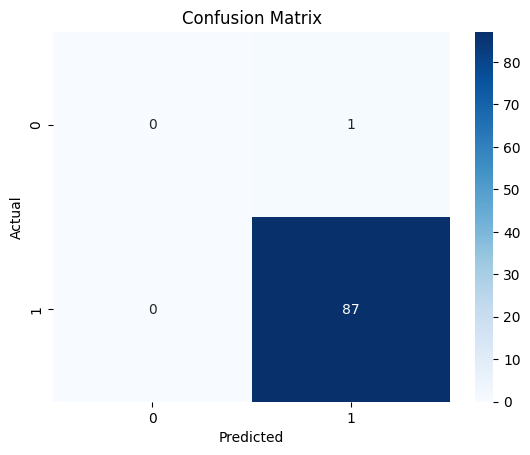

In [ ]:
preds_output = trainer.predict(test_dataset)
preds = np.argmax(preds_output.predictions, axis=1)
cm = confusion_matrix(test_labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# **Simpan model**

In [ ]:
model.save_pretrained("./bert_animal_condition_model")
tokenizer.save_pretrained("./bert_animal_condition_model")

('./bert_animal_condition_model/tokenizer_config.json',
 './bert_animal_condition_model/special_tokens_map.json',
 './bert_animal_condition_model/vocab.txt',
 './bert_animal_condition_model/added_tokens.json')

# **Skrip untuk memprediksi data baru**

In [ ]:
def predict_new_data(text):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", padding='max_length', truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    prediction = torch.argmax(outputs.logits, dim=-1).item()
    return prediction

# **Contoh prediksi**

In [ ]:
test_sample = "Fever, lethargy, loss of appetite."
predicted_label = predict_new_data(test_sample)
print(f"Predicted Label: {predicted_label}")

Predicted Label: 1
